# System identification

Step 5.9. A dynamic single-track model with saturating tires, fitted on the
identification runs of step 5.8 and checked on the validation runs. Mass, CG,
yaw inertia (`inertia.ipynb`) and wheel radius (`kinematic_model.ipynb`) are
fixed; the tire parameters and the steering lag are fitted.

## Model

Body frame at the CG, $x$ forward, $y$ left. States: lateral velocity $v_y$, yaw
rate $r$, and the steering angle $\delta$, which follows the command with a lag.
Inputs: steering command, rear wheel speed $u$ from the encoders, and $v_x$ from
the overhead video.

**Front**, one rolling tire:

$$\alpha_f = \delta - \arctan\frac{v_y + l_f r}{v_x}, \qquad
F_{yf} = \mu_f N_f \sin\big(C \arctan(B_f \alpha_f)\big)$$

**Rear**, the spool: two wheels at $\pm T/2$, both turning at the surface speed
$u$. Wheel $i$ sees the ground at $(v_x \mp \tfrac{T}{2} r,\; v_y - l_r r)$ and
slips by

$$\sigma_i = \frac{(v_{x,i} - u,\; v_{y,i})}{u}, \qquad
\mathbf{F}_i = -\frac{\mu_r N_r}{2} \sin\big(C \arctan(B_r |\sigma_i|)\big)
\frac{\sigma_i}{|\sigma_i|}$$

so each rear tire pushes against its own sliding direction: sideways when the
car turns, forward when the wheels spin. The forward forces of the two wheels
differ in a turn and give a yaw moment.

**Motion**, with $v_x$ given:

$$m(\dot v_y + v_x r) = F_{yf}\cos\delta + F_{y,L} + F_{y,R}$$
$$I_z \dot r = l_f F_{yf}\cos\delta - l_r (F_{y,L} + F_{y,R}) + \tfrac{T}{2}(F_{x,R} - F_{x,L})$$
$$\dot\delta = (\delta_{cmd} - \delta)/\tau$$

with $\delta_{cmd}$ from the steering map below.

Static axle loads $N_f = m g\, l_r/L$, $N_r = m g\, l_f/L$. Fitted: $\mu_f, B_f,
\mu_r, B_r, C$ and $\tau$.

A single rear contact point does not work: the spool makes the rear wheels turn
~15% faster than the axle moves even in slow grip turns (inner wheel slipping
forward, outer backward), and one contact point reads that as wheelspin.
Fitted on the drift run it needed mu = 2 against 0.25 measured and diverged on
validation. With two wheels the slips cancel in a grip turn and add up in a
donut.

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

M, IZ = 2.015, 0.0125                 # inertia.ipynb
LF, LR, L, T = 0.0986, 0.0744, 0.173, 0.1745
G = 9.81
NF, NR = M * G * LR / L, M * G * LF / L

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Steering

The fit needs the front wheel angle while driving. Measured three ways.

**Static**, ruler on the floor as in `kinematic_model.ipynb`, new points between
0.35 and 0.49 rad. At 0.40 and 0.46 also reached from above (coming down from
0.52). Readings in mm.

In [2]:
def wheel_angle(side, d_front, d_back, base):
    # positive = pointing left, as in kinematic_model.ipynb
    d = d_back - d_front if side == 'left' else d_front - d_back
    return np.degrees(np.arctan(d / base))


def bicycle(left, right):
    return np.degrees(np.arctan(2 / (1 / np.tan(np.radians(left)) + 1 / np.tan(np.radians(right)))))


axis = (wheel_angle('left', 88.5, 88, 200) + wheel_angle('right', 99.5, 102.5, 200)) / 2

# (cmd [rad], reached from): (left front, left back, left base, right front, right back, right base)
ruler = {
    (0.35, 'below'): (70.5, 117, 120, 134, 69.5, 200),
    (0.40, 'below'): (67.5, 120, 120, 137.5, 68, 200),
    (0.40, 'above'): (70.5, 118, 100, 141.5, 65.5, 200),
    (0.46, 'below'): (65, 125, 120, 139.5, 61, 200),
    (0.46, 'above'): (68, 123.5, 100, 146.5, 61.5, 200),
    (0.49, 'below'): (69, 122.5, 100, 145.5, 63, 200),
}
rows = []
for (cmd, came_from), (lf, lb, lbase, rf, rb, rbase) in ruler.items():
    left = wheel_angle('left', lf, lb, lbase) - axis
    right = wheel_angle('right', rf, rb, rbase) - axis
    rows.append({'cmd [rad]': cmd, 'from': came_from, 'left [deg]': left, 'right [deg]': right,
                 'delta [deg]': bicycle(left, right)})
static = pd.DataFrame(rows).round(2)
static

,cmd [rad],from,left [deg],right [deg],delta [deg]
0,0.35,below,21.68,18.38,19.90
1,0.40,below,24.13,19.66,21.68
2,0.40,above,25.91,21.31,23.40
3,0.46,below,27.07,21.93,24.25
4,0.46,above,29.53,23.53,26.21
5,0.49,below,28.65,22.92,25.49


From above the wheels stop 1.7 deg further at 0.40 and 2.0 deg at 0.46: play in
the linkage, held in place by the tires while the car stands.

**In motion**, from the steady parts of the identification runs, 1 s after each
step. The rear axle rolls straight there (sideslip under 1.5 deg), so
$\tan\delta = L r / v_x$.

In [3]:
rows = []
for name in ['id_steps', 'id_chirp', 'id_drift']:
    df = pd.read_parquet(f'../data/sysid/{name}.parquet')
    segment = ((df['cmd_steer'].diff().abs() > 1e-3) | (df['cmd_speed'].diff().abs() > 1e-2)).cumsum()
    for _, d in df.groupby(segment):
        w = d[d['t'] > d['t'].iloc[0] + 1.0]
        if len(w) < 50 or w['cmd_speed'].iloc[0] < 0.3 or abs(w['beta_rear'].median()) > 5:
            continue
        vx = w['v_cg'] * np.cos(np.radians(w['beta_cg']))
        rows.append({'run': name, 't [s]': w['t'].iloc[0], 'cmd [rad]': round(w['cmd_steer'].iloc[0], 2),
                     'v [m/s]': vx.median(), 'rear sideslip [deg]': w['beta_rear'].median(),
                     'delta [deg]': np.degrees(np.arctan(L * w['r'] / vx)).median()})
moving = pd.DataFrame(rows).round(2)
moving

,run,t [s],cmd [rad],v [m/s],rear sideslip [deg],delta [deg]
0,id_steps,2.72,0.40,0.51,0.80,25.10
1,id_steps,8.74,0.52,0.49,1.29,28.87
2,id_steps,11.76,0.40,0.51,0.14,24.55
3,id_steps,14.76,0.52,0.48,0.55,28.96
4,id_steps,17.78,0.40,0.50,1.12,24.88
5,id_steps,20.82,0.52,0.48,0.18,28.84
6,id_steps,23.82,0.40,0.50,0.63,24.76
7,id_steps,26.84,0.52,0.48,1.02,28.93
8,id_steps,29.86,0.40,0.50,0.70,24.35
9,id_chirp,2.68,0.46,0.49,0.69,26.49


2-3 deg above the static values from 0.40 up, and no hysteresis: the first 0.40
segment of id_steps comes from below (25.1 deg), the others from above
(24.4-24.9). Rolling tires do not hold the play. At 0.35 the release run
(validation, not used here) gives 20.2 deg in motion against 19.9 static.

**Servo on the stand**, car lifted, front-left wheel filmed from above at 240 fps
(`data/video/servo.mov`) with a strip of white tape along the tread. The command
stepped 0.40 <-> 0.52 six times, then 0 <-> 0.52 twice, 1.52 s apart. The file
plays at 30 fps; the command period is 364 frames, so 240 frames per real
second. The tape angle comes from the image moments. With the suspension hanging
and no load the angles differ from the floor ones, so only the timing is used.

In [4]:
FPS = 240
Y0, Y1, X0, X1 = 680, 980, 200, 470      # crop around the front-left wheel

cap = cv2.VideoCapture('../data/video/servo.mov')
angle = []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    hsv = cv2.cvtColor(frame[Y0:Y1, X0:X1], cv2.COLOR_BGR2HSV)
    tape = ((hsv[..., 2] > 140) & (hsv[..., 1] < 60)).astype(np.uint8)
    n, lab, st, _ = cv2.connectedComponentsWithStats(tape)
    # the floor is bright too but touches the crop border, the tape does not
    inside = (st[:, 0] > 0) & (st[:, 1] > 0) & (st[:, 0] + st[:, 2] < X1 - X0) & (st[:, 1] + st[:, 3] < Y1 - Y0)
    k = np.argmax(np.where(inside, st[:, 4], 0))
    m = cv2.moments((lab == k).astype(np.uint8), True)
    theta = 0.5 * np.degrees(np.arctan2(2 * m['mu11'], m['mu20'] - m['mu02']))
    angle.append(90 - theta % 180)      # from the image vertical, positive = left
angle = np.array(angle)

onsets = []
for i in np.where(np.abs(angle[10:] - angle[:-10]) > 2)[0]:
    if not onsets or i - onsets[-1] > 100:
        onsets.append(i)

rows = []
for i in onsets:
    a, b = np.median(angle[i - 60:i - 10]), np.median(angle[i + 120:i + 300])
    y = (angle[i - 40:i + 150] - a) / (b - a)
    i0, i20, i80 = np.argmax(y > 0.05), np.argmax(y > 0.2), np.argmax(y > 0.8)
    rows.append({'from [deg]': a, 'to [deg]': b,
                 't63 [ms]': 1000 * (np.argmax(y > 0.632) - i0) / FPS,
                 't98 [ms]': 1000 * (np.argmax(y > 0.98) - i0) / FPS,
                 'rate 20-80% [deg/s]': (y[i80] - y[i20]) * (b - a) / ((i80 - i20) / FPS)})
servo = pd.DataFrame(rows).round(1)
servo

,from [deg],to [deg],t63 [ms],t98 [ms],rate 20-80% [deg/s]
0,25.7,32.6,29.2,70.8,132.5
1,32.6,26.3,37.5,75.0,-113.6
2,26.3,32.7,29.2,70.8,136.7
3,32.7,26.3,37.5,70.8,-117.0
4,26.3,32.7,25.0,66.7,138.8
5,32.7,26.2,37.5,70.8,-115.1
6,26.3,32.7,25.0,66.7,140.6
7,32.7,26.3,37.5,79.2,-113.7
8,26.3,32.7,25.0,66.7,136.0
9,32.7,26.3,37.5,75.0,-113.9


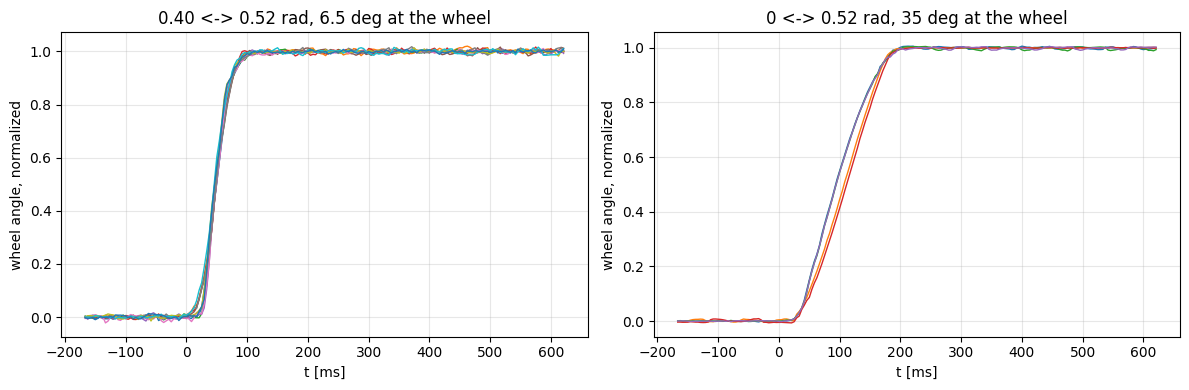

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i in onsets:
    a, b = np.median(angle[i - 60:i - 10]), np.median(angle[i + 120:i + 300])
    t = 1000 * (np.arange(i - 40, i + 150) - i) / FPS
    ax[0 if abs(b - a) < 15 else 1].plot(t, (angle[i - 40:i + 150] - a) / (b - a), lw=1)
ax[0].set_title('0.40 <-> 0.52 rad, 6.5 deg at the wheel')
ax[1].set_title('0 <-> 0.52 rad, 35 deg at the wheel')
for x in ax:
    x.set_xlabel('t [ms]')
    x.set_ylabel('wheel angle, normalized')
    x.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Small steps: 63% in 25-38 ms (slower back toward the center), settled in ~70 ms.
Large steps are rate limited, a straight ramp at ~250 deg/s at the wheel, 0 to
0.52 in ~145 ms. The delay from the command to the servo (micro-ROS, 50 Hz PWM)
is not in this video.

Map used below: static points up to 0.35 rad, in-motion medians from 0.40 up.

In [6]:
# steering map: static up to 0.35 rad (kinematic_model.ipynb, ruler above), in motion from 0.40
in_motion = moving.groupby('cmd [rad]')['delta [deg]'].median()
CMD = np.array([0, 0.15, 0.30, 0.35, 0.40, 0.46, 0.52])
DEL = np.radians([0.63, 9.33, 17.83, static['delta [deg]'].iloc[0], *in_motion[[0.40, 0.46, 0.52]]])
print('map [deg]:', np.degrees(DEL).round(2))


def load(name, t0, t1):
    df = pd.read_parquet(f'../data/sysid/{name}.parquet')
    df = df[(df['t'] >= t0) & (df['t'] <= t1)].reset_index(drop=True)
    df['vx'] = (df['v_cg'] * np.cos(np.radians(df['beta_cg']))).interpolate().bfill().ffill()
    df['u'] = df['v_wheels'].interpolate().bfill().ffill()
    df['delta'] = np.interp(df['cmd_steer'], CMD, DEL)
    return df


WINDOWS = {'id_steps': (3, 31), 'id_chirp': (3, 25.5), 'id_drift': (2.5, 15.5),
           'val_steps': (3, 31), 'val_chirp': (3, 25.5), 'val_drift': (2.5, 15.5), 'release': (2.5, 13.8)}
runs = {name: load(name, *w) for name, w in WINDOWS.items()}

map [deg]: [ 0.63  9.33 17.83 19.9  24.76 26.49 28.9 ]


In [7]:
def rear_wheel(vx, vy, u, mu, b, c):
    sx, sy = (vx - u) / max(u, 0.1), vy / max(u, 0.1)
    s = np.hypot(sx, sy) + 1e-9
    f = mu * NR / 2 * np.sin(c * np.arctan(b * s))
    return -f * sx / s, -f * sy / s


def rhs(x, p, vx, u, delta_cmd):
    mu_f, bf, mu_r, br, c, tau = p
    vy, r, d = x
    fyf = mu_f * NF * np.sin(c * np.arctan(bf * (d - np.arctan((vy + LF * r) / vx))))
    fxl, fyl = rear_wheel(vx - T / 2 * r, vy - LR * r, u, mu_r, br, c)
    fxr, fyr = rear_wheel(vx + T / 2 * r, vy - LR * r, u, mu_r, br, c)
    vy_dot = (fyf * np.cos(d) + fyl + fyr) / M - vx * r
    r_dot = (LF * fyf * np.cos(d) - LR * (fyl + fyr) + T / 2 * (fxr - fxl)) / IZ
    return np.array([vy_dot, r_dot, (delta_cmd - d) / tau])


def simulate(p, df, h=0.002):
    # fixed-step RK4, inputs held over each 20 ms sample; starts from the measured state
    t, vx, u, dc = df['t'].to_numpy(), df['vx'].to_numpy(), df['u'].to_numpy(), df['delta'].to_numpy()
    beta0 = df['beta_cg'][:25]
    b0 = np.radians(beta0.mean()) if beta0.notna().any() else np.arctan(LR * df['r'][0] / vx[0])
    x = np.array([vx[0] * np.tan(b0), df['r'][:25].mean(), dc[0]])
    out = np.zeros((len(t), 3))
    out[0] = x
    for i in range(len(t) - 1):
        n = max(1, round((t[i + 1] - t[i]) / h))
        hh = (t[i + 1] - t[i]) / n
        for _ in range(n):
            k1 = rhs(x, p, vx[i], u[i], dc[i])
            k2 = rhs(x + hh / 2 * k1, p, vx[i], u[i], dc[i])
            k3 = rhs(x + hh / 2 * k2, p, vx[i], u[i], dc[i])
            k4 = rhs(x + hh * k3, p, vx[i], u[i], dc[i])
            x = x + hh / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        if not np.isfinite(x).all() or abs(x[1]) > 50:
            return np.full((len(t), 3), np.nan)
        out[i + 1] = x
    return out


def beta_deg(sim, df):
    return np.degrees(np.arctan2(sim[:, 0], df['vx']))

## Fit

Least squares on yaw rate (weight 1/0.2 rad/s) and CG sideslip (1/2 deg) over
the three identification runs together, so one parameter set has to cover grip
and drift. Fitted: the five tire parameters and the steering lag. Four starts
spread over the bounds all ended at the same point.

In [8]:
def residuals(p, dfs):
    res = []
    for df in dfs:
        s = simulate(p, df)
        if not np.isfinite(s).all():
            return np.full(sum(2 * len(d) for d in dfs), 1e3)
        b = df['beta_cg'].to_numpy()
        ok = np.isfinite(b)
        res.append((s[:, 1] - df['r']) / 0.2)
        res.append(np.r_[(beta_deg(s, df)[ok] - b[ok]) / 2.0, np.zeros((~ok).sum())])
    return np.concatenate(res)


ids = [runs['id_steps'], runs['id_chirp'], runs['id_drift']]
fit = least_squares(residuals, [0.4, 15, 0.25, 15, 1.0, 0.1], args=(ids,),
                    bounds=([0.05, 0.5, 0.05, 0.5, 0.5, 0.02], [1.5, 60, 1.5, 60, 2.0, 0.5]),
                    x_scale=[0.1, 5, 0.1, 5, 0.2, 0.03], diff_step=1e-3)
p = fit.x
cov = np.linalg.pinv(fit.jac.T @ fit.jac) * 2 * fit.cost / (len(fit.fun) - len(p))
params = pd.DataFrame({'value': p, '1 sigma': np.sqrt(np.diag(cov))},
                      index=['mu_f', 'B_f', 'mu_r', 'B_r', 'C', 'tau']).round(3)
params

,value,1 sigma
mu_f,0.449,0.072
B_f,60.000,8.751
mu_r,0.315,0.050
B_r,20.803,3.113
C,0.678,0.174
tau,0.169,0.016


In [9]:
# cornering stiffness at zero slip: dF/dalpha = mu N B C
print(f"front {p[0] * NF * p[1] * p[4]:.0f} N/rad, rear axle {p[2] * NR * p[3] * p[4]:.0f} N per unit slip")

# with C < 1 there is no peak, the force tends to mu N sin(C pi/2) at full slide
for name, i in [('front', 0), ('rear', 2)]:
    grad = np.zeros(len(p))
    grad[i] = np.sin(p[4] * np.pi / 2)
    grad[4] = p[i] * np.cos(p[4] * np.pi / 2) * np.pi / 2
    print(f"{name} at full slide: {p[i] * np.sin(p[4] * np.pi / 2):.3f} +- {np.sqrt(grad @ cov @ grad):.3f}")

front 155 N/rad, rear axle 50 N per unit slip
front at full slide: 0.393 +- 0.004
rear at full slide: 0.276 +- 0.002


C < 1: the curves rise to $\mu N \sin(C\pi/2)$ and stay there, no peak, which
fits hard PVC. mu and C trade against each other, hence their wide sigmas, but the
force at full slide is pinned: **0.276 +- 0.002 at the rear**, 11% above the 0.248
of the straight launches (`handling.ipynb`), an independent test; 0.39 at the
front. B_f sits on its bound: the front is stiffer than these runs can resolve
(155 N/rad at the bound), because below the limit the front slip angles stay
under a degree.

**tau = 0.17 s**, against 25-40 ms for the servo alone on the stand, plus up to
20 ms of PWM period. Most of the lag is between the wheel angle and the tire
force, likely the tire relaxation (0.13 s is ~6 cm of rolling at 0.5 m/s). One
lumped lag covers it at the speeds of these runs.

## Tire curves

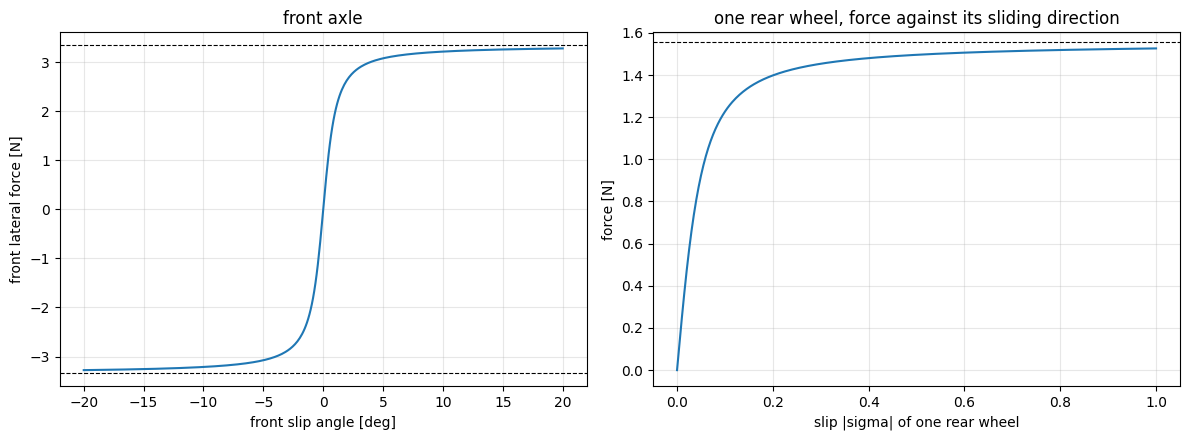

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
a = np.radians(np.linspace(-20, 20, 400))
ax[0].plot(np.degrees(a), p[0] * NF * np.sin(p[4] * np.arctan(p[1] * a)))
full = np.sin(p[4] * np.pi / 2)
ax[0].axhline(p[0] * NF * full, ls='--', color='k', lw=0.8)
ax[0].axhline(-p[0] * NF * full, ls='--', color='k', lw=0.8)
ax[0].set_xlabel('front slip angle [deg]')
ax[0].set_ylabel('front lateral force [N]')
ax[0].set_title('front axle')
s = np.linspace(0, 1, 400)
ax[1].plot(s, p[2] * NR / 2 * np.sin(p[4] * np.arctan(p[3] * s)))
ax[1].axhline(p[2] * NR / 2 * full, ls='--', color='k', lw=0.8)
ax[1].set_xlabel('slip |sigma| of one rear wheel')
ax[1].set_ylabel('force [N]')
ax[1].set_title('one rear wheel, force against its sliding direction')
for x in ax:
    x.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Validation

Two ways. Open loop over the whole run, which is a hard test inside the donut:
there small errors grow and the simulated car wanders from the real one. And
1 s ahead from the measured state, restarted every second, which is how the
NMPC will use the model.

In [11]:
def horizon_errors(p, df, h=1.0):
    er, eb, rr = [], [], []
    for a in np.arange(df['t'].iloc[0], df['t'].iloc[-1] - h, h):
        seg = df[(df['t'] >= a) & (df['t'] <= a + h)].reset_index(drop=True)
        s = simulate(p, seg)
        er.append(s[:, 1] - seg['r'])
        eb.append(beta_deg(s, seg) - seg['beta_cg'])
        rr.append(seg['r'])
    return np.concatenate(er), np.concatenate(eb), np.concatenate(rr)


rows = []
for name, df in runs.items():
    s = simulate(p, df)
    e_full = s[:, 1] - df['r']
    e_h, eb_h, r_h = horizon_errors(p, df)
    span = df['r'].max() - df['r'].min()
    rows.append({'run': name,
                 'yaw rms, full [rad/s]': np.sqrt(np.nanmean(e_full**2)),
                 'yaw NRMSE, full': np.sqrt(np.nanmean(e_full**2)) / span,
                 'sideslip rms, full [deg]': np.sqrt(np.nanmean((beta_deg(s, df) - df['beta_cg'])**2)),
                 'yaw rms, 1 s [rad/s]': np.sqrt(np.nanmean(e_h**2)),
                 'yaw NRMSE, 1 s': np.sqrt(np.nanmean(e_h**2)) / span,
                 'sideslip rms, 1 s [deg]': np.sqrt(np.nanmean(eb_h**2))})
validation = pd.DataFrame(rows).round(3)
validation

,run,"yaw rms, full [rad/s]","yaw NRMSE, full","sideslip rms, full [deg]","yaw rms, 1 s [rad/s]","yaw NRMSE, 1 s","sideslip rms, 1 s [deg]"
0,id_steps,0.088,0.126,1.569,0.087,0.124,1.554
1,id_chirp,0.111,0.192,1.222,0.116,0.201,1.264
2,id_drift,0.297,0.107,3.223,0.361,0.130,3.190
3,val_steps,0.102,0.107,1.610,0.103,0.108,1.577
4,val_chirp,0.120,0.168,1.468,0.122,0.171,1.421
5,val_drift,0.785,0.278,7.008,0.427,0.152,3.094
6,release,1.646,0.489,22.344,0.401,0.119,3.892


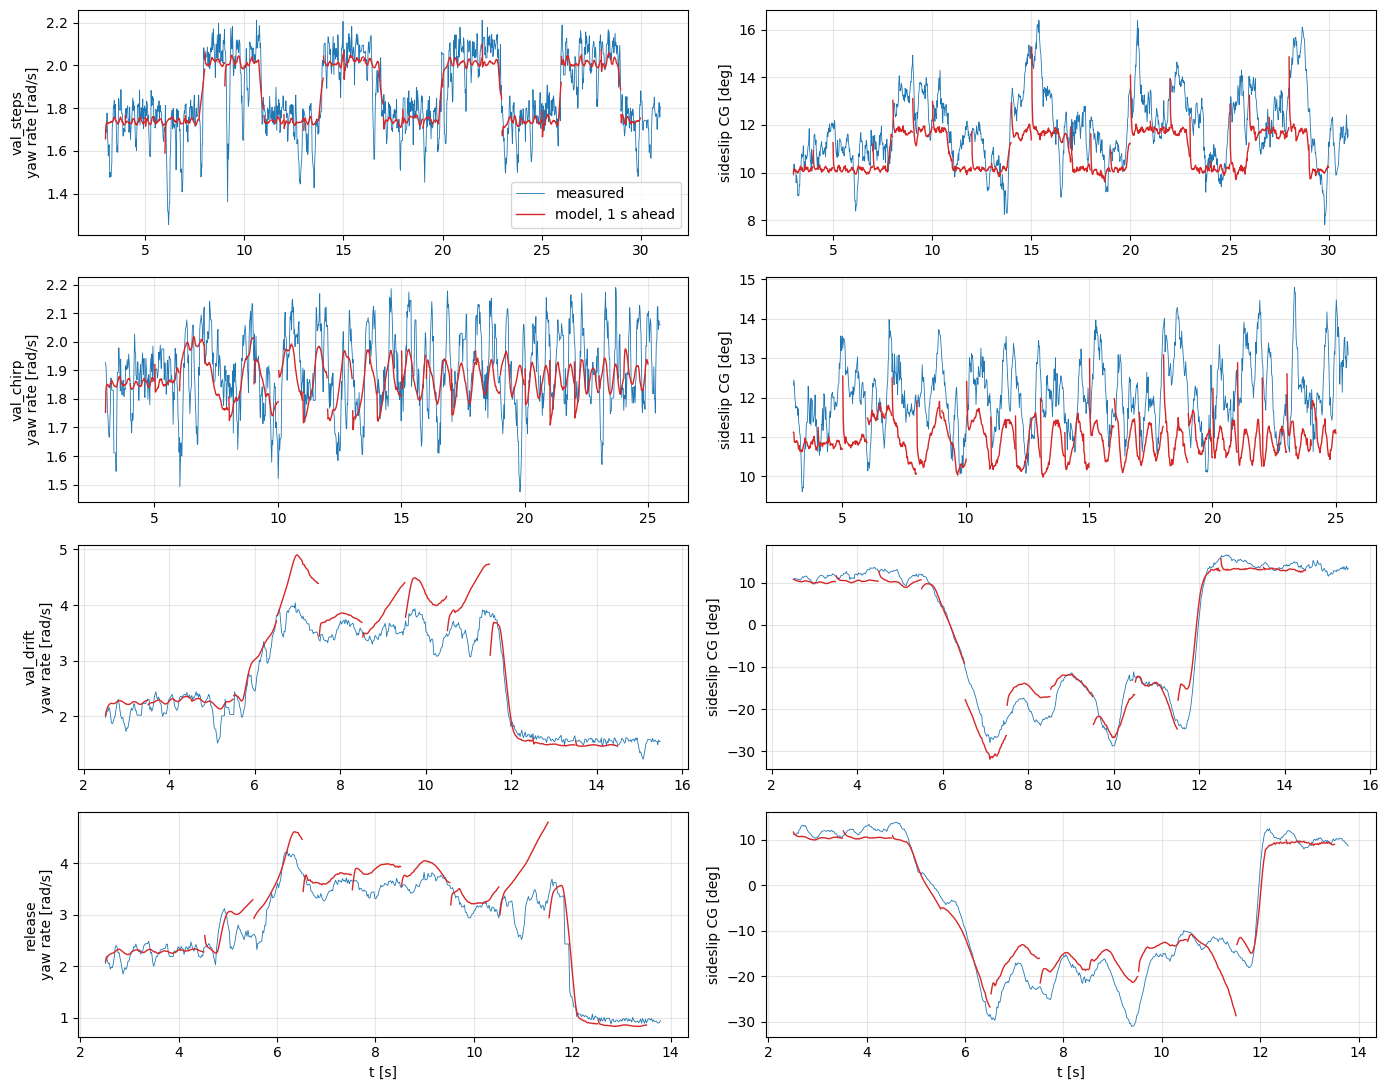

In [12]:
fig, ax = plt.subplots(4, 2, figsize=(14, 11))
for k, name in enumerate(['val_steps', 'val_chirp', 'val_drift', 'release']):
    df = runs[name]
    ax[k, 0].plot(df['t'], df['r'], lw=0.6, label='measured')
    ax[k, 1].plot(df['t'], df['beta_cg'], lw=0.6, label='measured')
    for a in np.arange(df['t'].iloc[0], df['t'].iloc[-1] - 1.0, 1.0):
        seg = df[(df['t'] >= a) & (df['t'] <= a + 1.0)].reset_index(drop=True)
        s = simulate(p, seg)
        ax[k, 0].plot(seg['t'], s[:, 1], color='C3', lw=1)
        ax[k, 1].plot(seg['t'], beta_deg(s, seg), color='C3', lw=1)
    ax[k, 0].set_ylabel(f'{name}\nyaw rate [rad/s]')
    ax[k, 1].set_ylabel('sideslip CG [deg]')
    for x in ax[k]:
        x.grid(alpha=0.3)
ax[0, 0].legend(['measured', 'model, 1 s ahead'])
ax[3, 0].set_xlabel('t [s]')
ax[3, 1].set_xlabel('t [s]')
plt.tight_layout()
plt.show()

## Result

One parameter set covers grip, the donut and the release. 1 s ahead, on the
validation runs: yaw rate within 0.10-0.12 rad/s in grip and 0.40-0.43 rad/s in
the drift (NRMSE 11-17%), sideslip within 1.4-1.6 deg in grip and 3.1-3.9 deg in
the drift. Open loop over a whole run it stays close in grip, but inside the
donut the simulated car wanders off (val_drift 0.8 rad/s): the drift is
sensitive, and the model is good for the short horizons an MPC uses, not for
replaying a whole drift.

What it misses: the model sideslip in grip runs ~1.1 deg under the video, a
constant offset (camera tilt, or the CG position); in the drift the yaw rate
comes out ~0.25 rad/s high on average, with an overshoot on drift entry; and
when the steering opens inside the donut (release, 10-11.5 s) it predicts a spin
the car did not do.

The steering map covers left turns; right of zero only the static map exists.